# Домашняя работа "Временные ряды, модель ARIMA"

## Задание

- Выберите ряд из первого задания.
- Постройте его модель ARIMA.
- Оформите отчёт в Jupyter-ноутбук.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import boxcox
from scipy.optimize import minimize

from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error

import statsmodels.api as sm
import statsmodels.tsa.api as smt
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA

%matplotlib inline

## Загрузим ряд

In [2]:
st_series = pd.read_csv("Series/monthly-boston-armed-robberies-j.csv")['Count']

In [3]:
def test_stationarity(timeseries):
    print('Results of Dickey-Fuller Test:')
    dftest = adfuller(timeseries, autolag='AIC')
    dfoutput = pd.Series(dftest[0:4], index=['Test Statistic', 'p-value', '#Lags Used', 'Number of Observations Used'])
    for [key, value] in dftest[4].items():
        dfoutput['Critical Value (%s)' % key] = value
    print(dfoutput)

def tsplot(y, lags=None, figsize=(14, 8), style='bmh'):
    test_stationarity(y)
    if not isinstance(y, pd.Series):
        y = pd.Series(y)
    with plt.style.context(style):
        plt.figure(figsize=figsize)
        layout = (5, 1)
        ts_ax = plt.subplot2grid(layout, (0, 0), rowspan=2)
        acf_ax = plt.subplot2grid(layout, (2, 0))
        pacf_ax = plt.subplot2grid(layout, (3, 0))
        qq_ax = plt.subplot2grid(layout, (4, 0))

        y.plot(ax=ts_ax, color='blue', label='Or')
        ts_ax.set_title('Original')

        smt.graphics.plot_acf(y, lags=lags, ax=acf_ax, alpha=0.05)
        smt.graphics.plot_pacf(y, lags=lags, ax=pacf_ax, alpha=0.05)
        sm.qqplot(y, line='s', ax=qq_ax)
        
        plt.tight_layout()
    return

Results of Dickey-Fuller Test:
Test Statistic                   1.001102
p-value                          0.994278
#Lags Used                      11.000000
Number of Observations Used    106.000000
Critical Value (1%)             -3.493602
Critical Value (5%)             -2.889217
Critical Value (10%)            -2.581533
dtype: float64


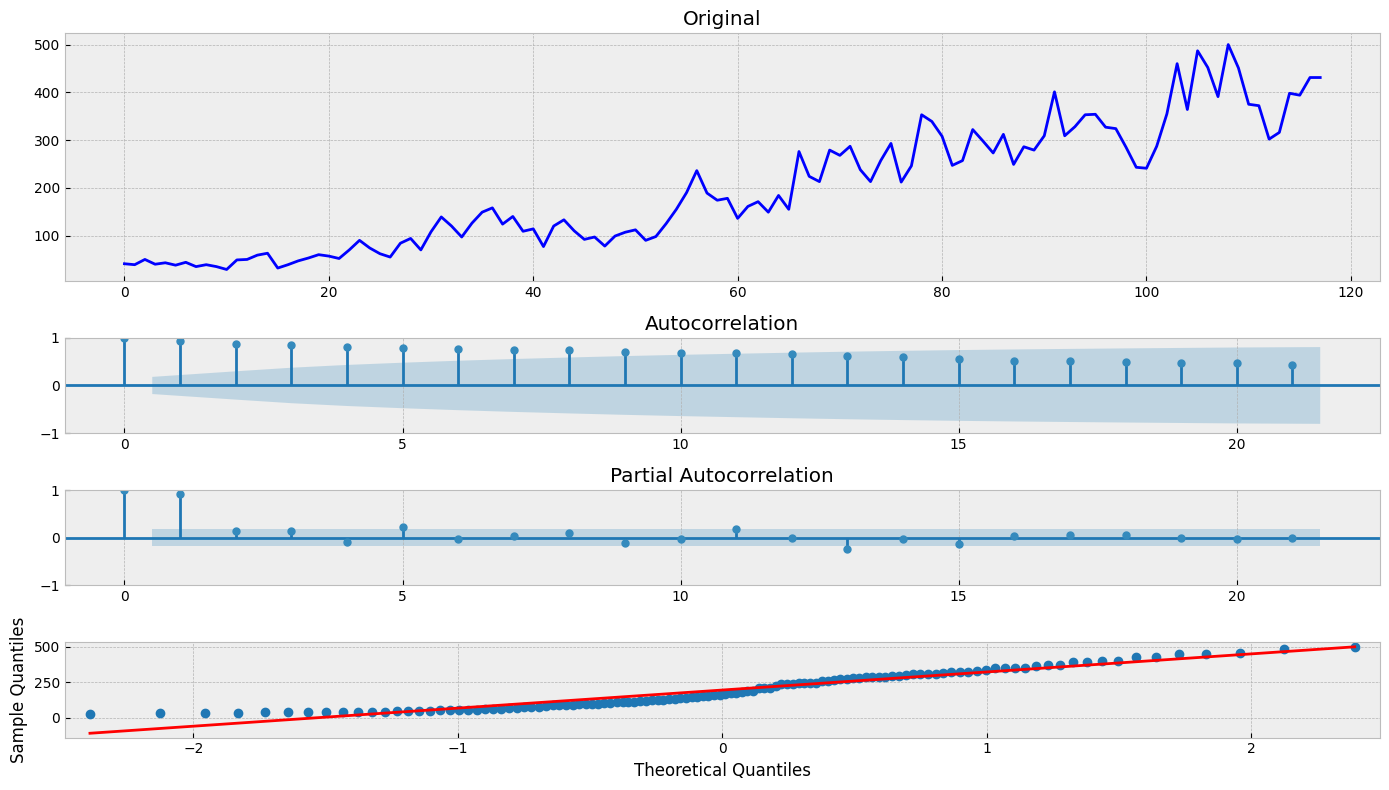

In [4]:
tsplot(st_series)

## Применим модель ARIMA

C:\Users\tyane\AppData\Local\Temp\ipykernel_4216\3665445979.py:16: UserWarning: Provided `endog` series has been differenced to eliminate integration prior to parameter estimation by method "innovations_mle".
  tmp_mdl = ARIMA(st_series, order=(i,d,j), trend=tr).fit(method=mthd)
c:\Edu\ML\TS - ARMA\.venv\lib\site-packages\statsmodels\tsa\arima\estimators\gls.py:134: UserWarning: Provided `endog` and `exog` series have been differenced to eliminate integration prior to GLS parameter estimation.
  warnings.warn('Provided `endog` and `exog` series have been'
C:\Users\tyane\AppData\Local\Temp\ipykernel_4216\3665445979.py:16: UserWarning: Provided `endog` series has been differenced to eliminate integration prior to parameter estimation by method "hannan_rissanen".
  tmp_mdl = ARIMA(st_series, order=(i,d,j), trend=tr).fit(method=mthd)
c:\Edu\ML\TS - ARMA\.venv\lib\site-packages\statsmodels\tsa\arima\estimators\gls.py:134: UserWarning: Provided `endog` and `exog` series have been differenced

aic: 1179.03187 | order: (3, 1, 3) method: innovations_mle trend t
Results of Dickey-Fuller Test:
Test Statistic                  -1.677315
p-value                          0.442837
#Lags Used                      12.000000
Number of Observations Used    105.000000
Critical Value (1%)             -3.494220
Critical Value (5%)             -2.889485
Critical Value (10%)            -2.581676
dtype: float64


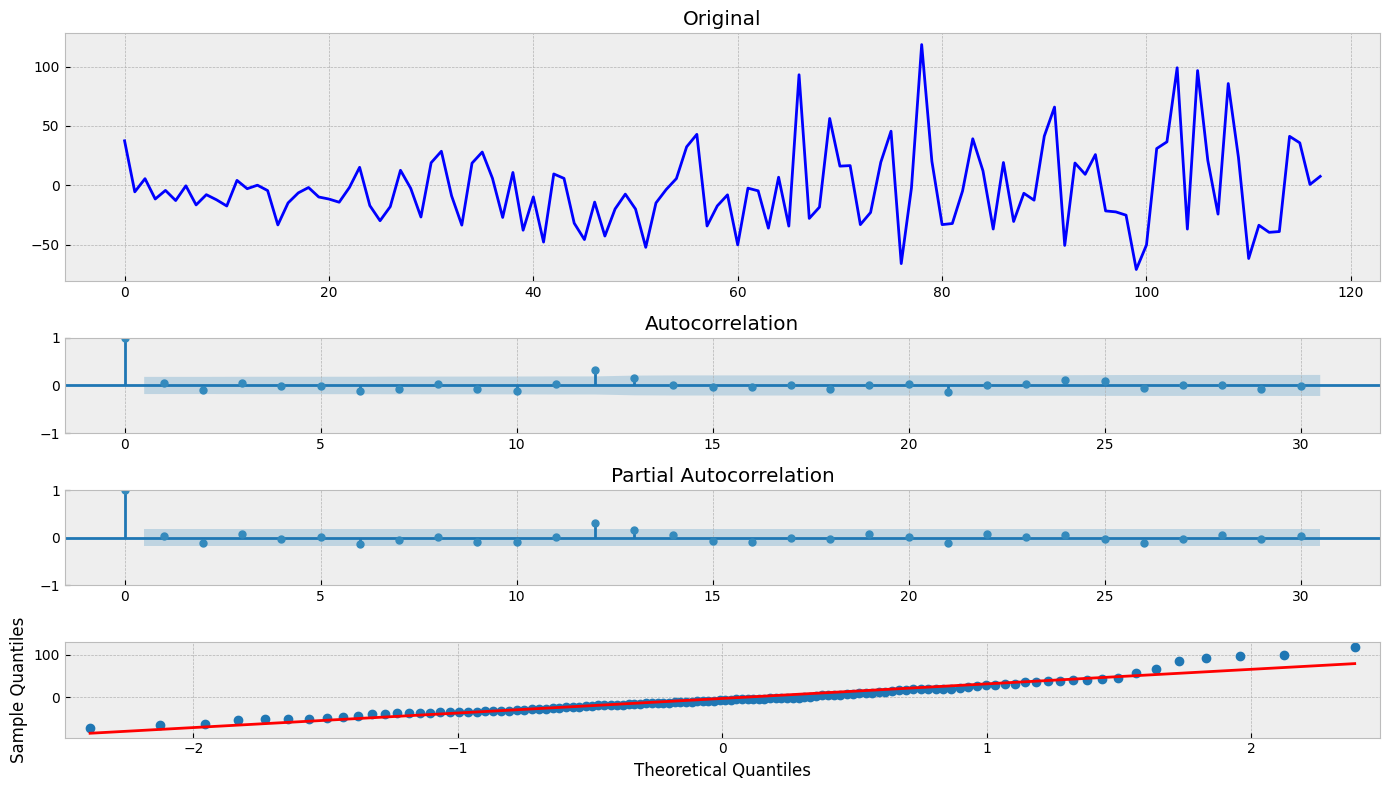

In [24]:
best_aic = np.inf 
best_order = None
best_mdl = None
best_mthd = None
best_trend = None

trends = ['n', 'c', 't', 'ct']
methods = ['statespace', 'innovations_mle', 'hannan_rissanen', 'innovations']

for i in range(5):
    for d in range(5):
        for j in range(5):
            for mthd in methods:
                for tr in trends:
                    try:
                        tmp_mdl = ARIMA(st_series, order=(i,d,j), trend=tr).fit(method=mthd)
                        tmp_aic = tmp_mdl.aic
                        if tmp_aic < best_aic:
                            best_aic = tmp_aic
                            best_order = (i, d, j)
                            best_mdl = tmp_mdl
                            best_mthd = mthd
                            best_trend = tr
                    except Exception as e: 
                        #print('Exception {} on: order: {} method: {} trend {}'.format(e, (i, d, j), mthd, tr))
                        continue


print('aic: {:6.5f} | order: {} method: {} trend {}'.format(best_aic, best_order, best_mthd, best_trend))


tsplot(best_mdl.resid, lags=30)

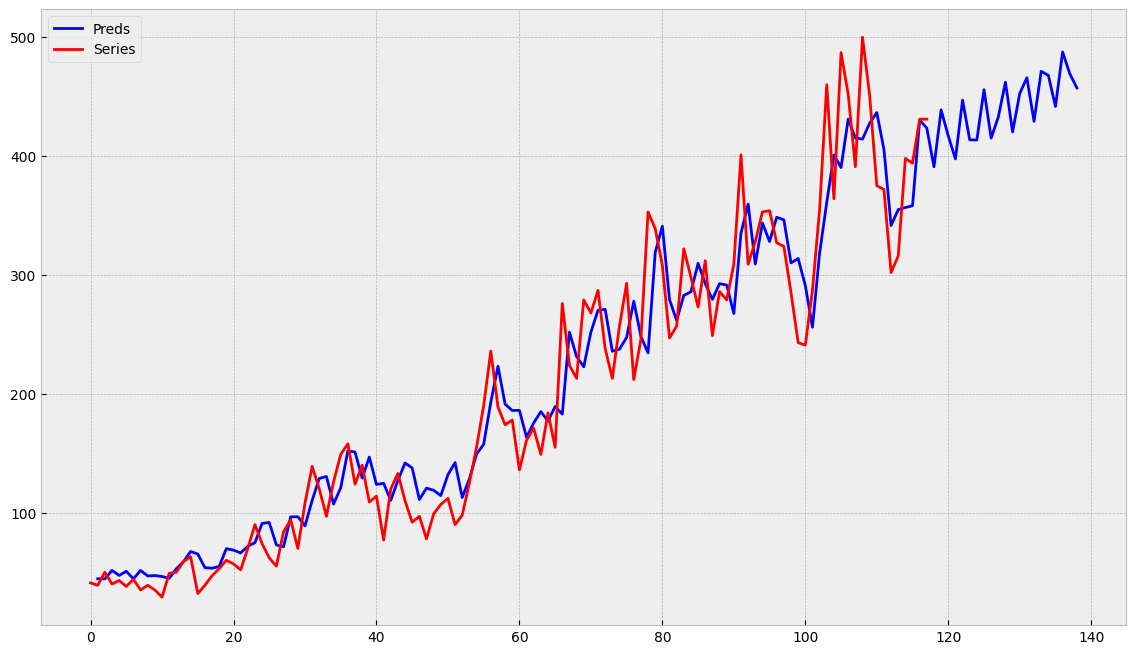

In [25]:
with plt.style.context('bmh'):
    plt.figure(figsize=(14,8))
    ax = plt.axes()
    predictions = best_mdl.predict(start=1, end=len(st_series)+20)
    plt.plot(predictions, color='blue', label='Preds')
    plt.plot(st_series, color='red', label='Series')
    plt.legend()
    plt.show()

## Выводы

Применил модель ARIMA для ряда monthly-boston-armed-robberies-j.csv

Помимо порядка порядок авторегрессии, дифференцирования и скользящего среднего попробовал варьировать еще и методы оценки параметров модели. Интересно, например, что метод Бурда вообще не работает с компонентой скользящего среднего, а некоторые значения тренда не применимы при d == 0

*Задание сделал на последней версии библиотеки statsmodel (на текущий момент 0.14.0), поскольку не смог установить устаревшую зависимость numpy, который нужен для statsmodels 0.12